In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Data
Dataset: UCI Diabetes 130-US Hospitals (1999–2008), ~101,766 encounters, 50 columns.
Goal of this section: confirm shape, dtypes, and get a first read on what we're working with before touching anything.

In [3]:
import pandas as pd
df = pd.read_csv('C:\\Users\\yomna\\Desktop\\readmission-project\\data\\diabetic_data.csv')

print(df.shape)
df.head()


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.sample(6)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
49491,149759640,96467742,Caucasian,Male,[70-80),?,1,7,7,1,...,No,No,No,No,No,No,No,No,No,NO
11433,47338038,63650547,Caucasian,Female,[80-90),[75-100),6,6,17,7,...,No,No,No,No,No,No,No,Ch,Yes,NO
81160,251038356,43140906,Caucasian,Female,[20-30),?,1,6,7,2,...,No,Down,No,No,No,No,No,Ch,Yes,<30
49086,149072802,60326847,AfricanAmerican,Female,[70-80),?,2,6,1,4,...,No,No,No,No,No,No,No,No,No,>30
82476,257015808,107774460,Caucasian,Male,[80-90),?,3,1,1,2,...,No,No,No,No,No,No,No,Ch,Yes,NO
68305,192639990,33448968,Caucasian,Female,[80-90),?,1,1,7,2,...,No,No,No,No,No,No,No,Ch,Yes,>30


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Dataset Feature Dictionary - Diabetes 130-US Hospitals (1999-2008)

This dataset contains 101,766 patient encounters from 130 US hospitals, where each row is one hospital admission of a patient with a diabetes diagnosis. The main goal is usually to predict hospital readmission (often within 30 days). Below is a grouped, plain-English breakdown of every feature.



### 1. Identifiers

These don't carry medical meaning - they just uniquely identify rows/patients.

| Feature | What it means |
|---|---|
| encounter_id | Unique ID for this specific hospital visit/encounter. |
| patient_nbr | Unique ID for the patient. Note: the same patient can appear multiple times (multiple encounters), so this is key for avoiding data leakage between train/test splits. |

---

### 2. Demographics

Basic information about the patient. These are sensitive attributes - handle with care regarding bias/fairness.

| Feature | What it means |
|---|---|
| race | Patient's race: Caucasian, African American, Asian, Hispanic, or Other. Contains missing values. |
| gender | Male, Female, or Unknown/Invalid. |
| age | Age bucketed into 10-year ranges: [0-10), [10-20), ... [90-100). |
| weight | Patient weight (in pounds). Mostly missing (about 97% missing) - usually dropped or treated as an "unknown" category. |

---

### 3. Admission and Discharge Details

Describes how and why the patient entered/left the hospital. These are coded as integer IDs that map to a separate lookup table (IDS_mapping.csv), so you'll want to decode them into readable labels.

| Feature | What it means |
|---|---|
| admission_type_id | Code (1-9) for how the patient was admitted - e.g., Emergency, Urgent, Elective, Newborn, or Not Available/Unknown. |
| discharge_disposition_id | Code (1-29) for where the patient went after discharge - e.g., discharged home, transferred to another facility, expired, left against medical advice. |
| admission_source_id | Code (1-21) for where the patient came from - e.g., physician referral, emergency room, transfer from another hospital. |
| time_in_hospital | Number of days between admission and discharge (length of stay), ranges 1-14 days by design. |

---

### 4. Care Team and Setting

| Feature | What it means |
|---|---|
| payer_code | Code identifying who is paying for the treatment (e.g., insurance type, Medicare, self-pay). Has missing values. |
| medical_specialty | Specialty of the admitting physician (e.g., Cardiology, Family/GeneralPractice, InternalMedicine). Has 53% missing values. |

---

### 5. Hospital Utilization (Volume Counts)

These describe how much clinical activity happened during this specific encounter - good indicators of severity/complexity.

| Feature | What it means |
|---|---|
| num_lab_procedures | Number of lab tests performed during the encounter. |
| num_procedures | Number of non-lab procedures performed (e.g., surgeries, other interventions). |
| num_medications | Number of distinct generic medications administered during the encounter. |
| number_outpatient | Number of outpatient visits by the patient in the year before this encounter. |
| number_emergency | Number of emergency room visits by the patient in the year before this encounter. |
| number_inpatient | Number of inpatient (hospital admission) visits by the patient in the year before this encounter. |
| number_diagnoses | Total number of diagnoses entered into the system for this encounter. |

Note: these "prior visit" counts (number_outpatient, number_emergency, number_inpatient) are often strong predictors of readmission - patients with a history of frequent visits tend to come back more.

---

### 6. Diagnoses

Each encounter can log up to three diagnosis codes (ICD-9 format), ordered roughly by clinical priority.

| Feature | What it means |
|---|---|
| diag_1 | Primary (main) diagnosis code. |
| diag_2 | Secondary diagnosis code. |
| diag_3 | Additional (tertiary) diagnosis code. |

These are raw ICD-9 codes (numeric/alphanumeric strings) - commonly grouped into broader disease categories (e.g., circulatory, respiratory, diabetes-related) during preprocessing since there are hundreds of unique raw codes.

---

### 7. Diabetes-Specific Lab Results

| Feature | What it means |
|---|---|
| max_glu_serum | Result of the glucose serum test, indicating range: >200, >300, Normal, or None (test not performed). |
| A1Cresult | Result of the HbA1c test (average blood sugar over about 3 months): >7, >8, Normal, or None (test not performed). This was the key variable studied in the original research paper behind this dataset. |

---

### 8. Medication Features

For each individual diabetes drug (23 in total, listed below), there's a column showing whether the dosage was kept steady, increased, decreased, or the drug wasn't prescribed during the encounter.

Possible values for each drug column: Up (dosage increased), Down (dosage decreased), Steady (no change), No (not prescribed).

The 23 medication columns:

metformin, repaglinide, nateglinide, chlorpropamide, glimepiride, acetohexamide, glipizide, glyburide, tolbutamide, pioglitazone, rosiglitazone, acarbose, miglitol, troglitazone, tolazamide, examide, citoglipton, insulin, glyburide-metformin, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone, metformin-pioglitazone

Note: many of these columns have almost no variation (e.g., examide, citoglipton are almost always "No") - worth checking value counts before using them as model features, since near-constant columns add little signal.

| Feature | What it means |
|---|---|
| change | Whether there was any change in diabetic medications (dosage or drug) during the encounter: Ch (changed) or No (no change). A summary flag across all the drug columns above. |
| diabetesMed | Whether any diabetes medication was prescribed at all during the encounter: Yes / No. |

---

### 9. Target Variable

| Feature | What it means |
|---|---|
| readmitted | Whether the patient was readmitted to the hospital: <30 (readmitted within 30 days), >30 (readmitted after 30 days), or NO (not readmitted). This is the typical prediction target, often binarized into <30 vs. everything else for the classic "30-day readmission" task. |

---

### Quick Recap - Grouping Summary

| Group | Purpose |
|---|---|
| Identifiers | Track rows/patients, not predictive |
| Demographics | Patient background (sensitive attributes) |
| Admission/Discharge | Encoded logistics of the hospital stay |
| Care team | Who treated the patient, who paid |
| Utilization counts | Encounter intensity and prior healthcare use |
| Diagnoses | What conditions were recorded |
| Lab results | Diabetes-specific test outcomes |
| Medications | Drug-by-drug dosage changes |
| Target | What you're trying to predict |

---

#### Notes for preprocessing
- weight, payer_code, and medical_specialty have heavy missingness, gonna decide whether to drop, impute, or bucket as "Missing"/"Unknown" category..
- admission_type_id, discharge_disposition_id, admission_source_id need to be joined with IDS_mapping.csv to get human-readable labels.
- diag_1/2/3 typically need grouping into higher-level ICD-9 categories to be usable (too many unique raw codes otherwise).
- Since patient_nbr repeats for patients with multiple encounters, split train/test by patient, not by row, to avoid leakage.

## 2. Missing Values
"?" placeholders need to be converted to real NaN before we can measure missingness properly.
These are all categorical columns, so we fill missing values with an explicit "Missing" category
rather than mean/median (which only makes sense for continuous numbers).

In [10]:
#convert '?' to real NaN and measure missingness
df_clean = df.replace('?', np.nan)

missing_pct = df_clean.isnull().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [11]:
#duplicate rows check
print("Fully duplicate rows:", df_clean.duplicated().sum())

Fully duplicate rows: 0


In [12]:
#fill categorical missing values with "Missing"
cols_to_fill = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code', 'race']

for col in cols_to_fill:
    df_clean[col] = df_clean[col].fillna('Missing')

# verify: should all be 0 now
df_clean[cols_to_fill].isnull().sum()

weight               0
max_glu_serum        0
A1Cresult            0
medical_specialty    0
payer_code           0
race                 0
dtype: int64

all 6 columns show 0, meaning there are no more actual missing values left.

In [13]:
#sanity check: print the value counts of the filled columns to see how many "Missing" values were added
for col in cols_to_fill:
    print(f"\n{col}:")
    print(df_clean[col].value_counts().head())


weight:
weight
Missing      98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
Name: count, dtype: int64

max_glu_serum:
max_glu_serum
Missing    96420
Norm        2597
>200        1485
>300        1264
Name: count, dtype: int64

A1Cresult:
A1Cresult
Missing    84748
>8          8216
Norm        4990
>7          3812
Name: count, dtype: int64

medical_specialty:
medical_specialty
Missing                   49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Name: count, dtype: int64

payer_code:
payer_code
Missing    40256
MC         32439
HM          6274
SP          5007
BC          4655
Name: count, dtype: int64

race:
race
Caucasian          76099
AfricanAmerican    19210
Missing             2273
Hispanic            2037
Other               1506
Name: count, dtype: int64


In [14]:
df.duplicated().sum()

np.int64(0)

returned 0, meaning no two rows are identical across all 50 columns!

## 3. Discharge Disposition - filtering out patients who cannot be readmitted
Some `discharge_disposition_id` codes mean the patient died or entered hospice. These cases are structurally incapable of being "readmitted," so leaving them in would bias the negative class. We filter these out *before* looking at target distribution, so our imbalance number reflects the real modeling population, not a temporarily-inflated one.

There are three kinds of patients mixed in this column:

* Normal patients who left the hospital alive (went home, transferred, etc.)
* Patients who died or went to hospice (codes 11, 13, 14, 19, 20, 21)
* Patients whose code is just unclear/not recorded properly (codes 18, 25, 26), not dead, just messy data

In [15]:
df_clean['discharge_disposition_id'].value_counts().head(15)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
Name: count, dtype: int64

In [16]:
expired_hospice_codes = [11, 13, 14, 19, 20, 21]
unknown_codes = [18, 25, 26]  # Not Mapped / Unknown-Invalid / NULL

n_before = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(expired_hospice_codes)]
n_after_expired = len(df_clean)
print(f"Removed {n_before - n_after_expired} expired/hospice rows")

print("Rows with unknown/not-mapped discharge codes:",
      df_clean['discharge_disposition_id'].isin(unknown_codes).sum())

Removed 2423 expired/hospice rows
Rows with unknown/not-mapped discharge codes: 4680


**Finding:** removed 2423 encounters coded as expired or hospice discharge, these cannot be readmitted by definition, so keeping them would artificially inflate the "no readmission" class.
Separately, 4680 rows carry "unknown/not mapped" discharge codes; these are missing-information cases, not expired patients.

**Decision Taken regarding the 4,680 rows that carry "unknown/not mapped":** discharge codes 18, 25, and 26 mean "Not Mapped," "Unknown/Invalid," and "NULL" — they don't tell us anything real about where the patient went, they're just missing/unclear records, not expired or hospice patients.

To keep this consistent with how we handled other missing data earlier (weight, payer_code, etc.), we relabel these three codes as "Missing" instead of leaving them as separate, meaningless numbers. This way, `discharge_disposition_id` won't accidentally be treated as having real distinct categories for information the hospital simply never had.

In [17]:
# Relabel unknown/not-mapped discharge codes (18, 25, 26) as "Missing"
# First convert the column to text, since we're mixing numbers with a text label
df_clean['discharge_disposition_id'] = df_clean['discharge_disposition_id'].astype(str)

unknown_codes_str = ['18', '25', '26']
df_clean['discharge_disposition_id'] = df_clean['discharge_disposition_id'].replace(unknown_codes_str, 'Missing')

# verify: unknown numeric codes should be gone, replaced by "Missing"
df_clean['discharge_disposition_id'].value_counts().loc[lambda x: x.index.isin(['Missing', '18', '25', '26'])]

discharge_disposition_id
Missing    4680
Name: count, dtype: int64

All 4,680 rows from codes 18, 25, and 26 are now merged into a single "Missing" category, and none of the individual codes (18, 25, 26) show up separately anymore; meaning the replace worked cleanly!!

## 4. Target Variable: `readmitted`
Original: 3 classes (`<30`, `>30`, `NO`). Collapsed to binary: `<30` = 1, everything else = 0.
Computed *after* removing expired/hospice rows, so this is the real imbalance we'll model against.

In [18]:
df_clean['readmitted_binary'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean['readmitted_binary'].value_counts(normalize=True) * 100

readmitted_binary
0    88.611175
1    11.388825
Name: proportion, dtype: float64

**Finding:** 11.39% of remaining encounters are <30-day readmissions, 88.61% are not; this is slightly higher than the commonly-cited ~11% figure, since we already removed expired/hospice cases (which were always "not readmitted") before this calculation. That's expected, not a mistake! it's exactly why we moved this step after the discharge disposition filtering. 

*** Confirms strong class imbalance .. recall will matter more than accuracy going forward.

## 5. Repeat Patients
The dataset tracks encounters, not unique patients; the same person can appear multiple times. This matters for splitting train/test correctly later (by patient, not by row) to avoid leakage.

In [19]:
n_unique_patients = df_clean['patient_nbr'].nunique()
n_encounters = len(df_clean)
print(f"{n_unique_patients} unique patients across {n_encounters} encounters")
print(f"Average encounters per patient: {n_encounters / n_unique_patients:.2f}")

69990 unique patients across 99343 encounters
Average encounters per patient: 1.42


It's normal to look like that, since some patients came in more than once, `n_unique_patients` will be smaller than `n_encounters`

## 6. Readmission Rate by Prior Utilization
Hypothesis (from literature): `number_inpatient` is the single strongest predictor of readmission.

The idea: i'm testing whether patients who've been hospitalized many times before (in the year prior) are more likely to come back again within 30 days this time. The hypothesis from research is: yes, prior hospital visits are one of the strongest warning signs.

**A note**: Inpatient = a patient who is formally admitted and stays overnight (or longer) in the hospital.. 
number_inpatient specifically means: "how many times was this patient formally admitted to a hospital (stayed overnight) in the year before this current visit?"

and Outpatient = when someone goes to the hospital/clinic for something (a test, a checkup, a minor procedure) and leave the same day, no overnight stay, no bed assigned.

Group all patients by how many prior inpatient visits they had (0, 1, 2, 3...), and for each group, calculate the average of readmitted_binary

In [20]:
readmit_by_inpatient = df_clean.groupby('number_inpatient')['readmitted_binary'].mean()
readmit_by_inpatient.head(10)

number_inpatient
0    0.085893
1    0.132533
2    0.179315
3    0.210333
4    0.241423
5    0.319848
6    0.348101
7    0.362595
8    0.462069
9    0.431193
Name: readmitted_binary, dtype: float64

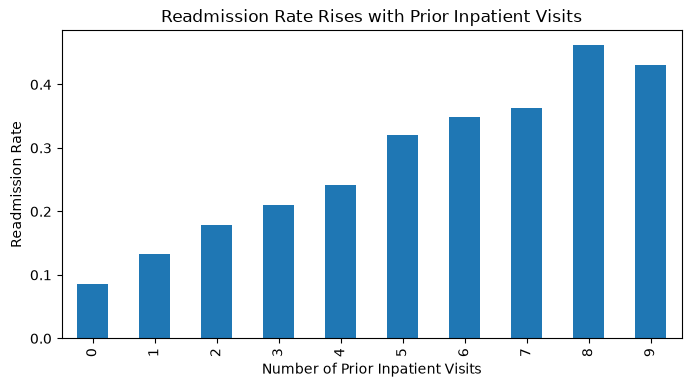

In [21]:
readmit_by_inpatient.head(10).plot(kind='bar', figsize=(8,4))
plt.xlabel('Number of Prior Inpatient Visits')
plt.ylabel('Readmission Rate')
plt.title('Readmission Rate Rises with Prior Inpatient Visits')
plt.show()

**Finding:** readmission rate at 0 prior inpatient visits is ~8.6%, rising steadily to ~46% at 8 prior visits (dropping slightly at 9, likely due to a small sample size in that group). This strongly confirms `number_inpatient` as a powerful signal, consistent with literature, and likely to be one of the most important features when we get to feature importance in modeling.

## 7. Age, Length of Stay, and Medication Count
Checking three more features named explicitly in the project spec. Age is converted to an ordered category first; it's currently sorted alphabetically by coincidence (all bins start with one digit), so making the order explicit avoids relying on that coincidence.

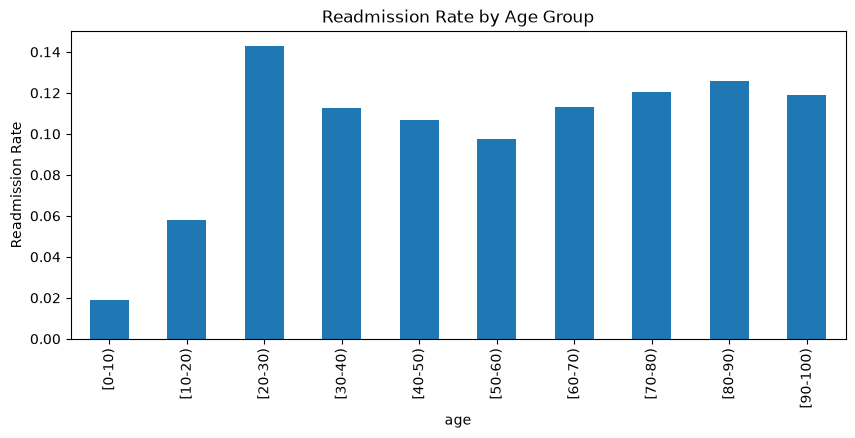

In [22]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df_clean['age'] = pd.Categorical(df_clean['age'], categories=age_order, ordered=True)

df_clean.groupby('age')['readmitted_binary'].mean().plot(kind='bar', figsize=(10,4))
plt.title('Readmission Rate by Age Group')
plt.ylabel('Readmission Rate')
plt.show()

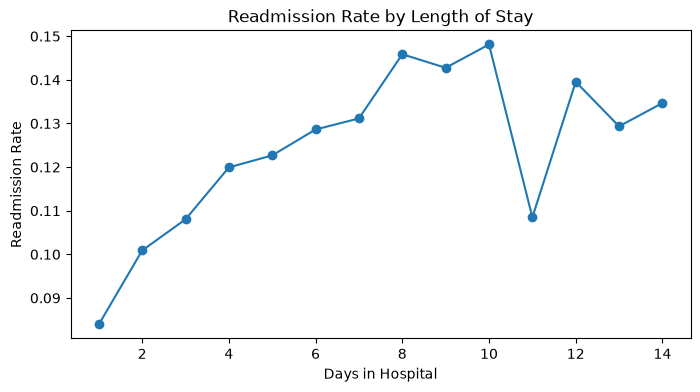

In [23]:
df_clean.groupby('time_in_hospital')['readmitted_binary'].mean().plot(kind='line', marker='o', figsize=(8,4))
plt.title('Readmission Rate by Length of Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate')
plt.show()

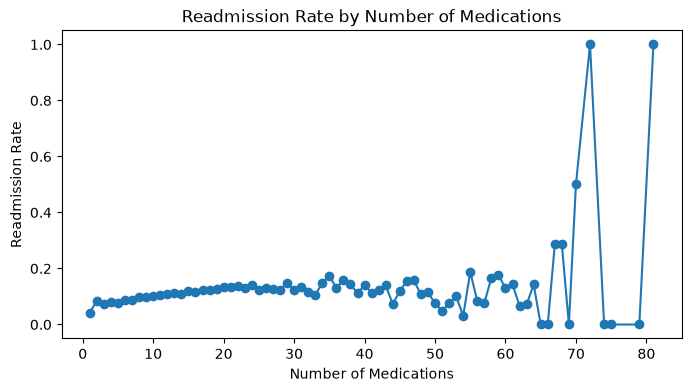

In [24]:
df_clean.groupby('num_medications')['readmitted_binary'].mean().plot(kind='line', marker='o', figsize=(8,4))
plt.title('Readmission Rate by Number of Medications')
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate')
plt.show()

**Finding - Age:** Readmission rate does not rise cleanly with age. The youngest group ([0-10)) has the lowest rate (~2%), but the [20-30) group unexpectedly shows the highest rate of any age bracket (~14.3%) higher than any elderly group. Rates dip through middle age ([40-60): ~10-11%) before climbing again for older patients (~12-13% for 70+). The [20-30) spike is likely inflated by a much smaller sample size in that bracket (diabetes-related hospitalization is far less common in young adults), so this finding should be treated as noisy rather than a strong signal.

**Finding - Length of Stay:** A real upward trend: readmission rate rises steadily from ~8.4% at 1 day to ~14-15% around 8-10 days, consistent with longer stays reflecting sicker or more complex patients; past day 10, the line becomes noisy (e.g. a drop at day 11, spike at day 12), which reflects the much smaller number of patients with very long stays (11-14 days), making those individual rates less statistically reliable.

**Finding - Number of Medications:** Roughly flat and weak for 1-60 medications (readmission rate hovers around 0.10-0.15), suggesting only a mild relationship in the range where most patients fall. Beyond ~65 medications, the rate swings wildly between 0.0 and 1.0 this is a small-sample artifact, not a real trend: almost no patients are prescribed that many distinct medications, so a group of 1-2 patients produces an all-or-nothing readmission rate. This instability should be noted so it isn't mistaken for a genuine pattern later during feature engineering or modeling.

**Overall:** unlike `number_inpatient` (Block 6), none of these three features show as strong or as clean a relationship with readmission. Age and length of stay show mild, partially noisy trends; number of medications is essentially flat except for an unreliable tail caused by tiny sample sizes. This is itself a useful finding, not every feature needs to be a strong predictor to be worth reporting, and it helps set expectations for which features will likely dominate later in feature importance.

## 8. Diagnosis Codes — Raw Glance

The `diag_1`, `diag_2`, and `diag_3` columns hold the patient's primary and secondary diagnoses, coded using **ICD-9** ; a standardized numeric system used across US hospitals to classify diseases and medical conditions. This is a completely different coding system from the admission/discharge codes we handled earlier (those came from `IDs_mapping.csv`); ICD-9 codes are medical diagnosis codes, not administrative ones.
## 8. Diagnosis Codes — Raw Glance

The `diag_1`, `diag_2`, and `diag_3` columns hold the patient's primary and secondary diagnoses, coded using **ICD-9**, a standardized numeric system used across US hospitals to classify diseases and medical conditions. This is a completely different coding system from the admission/discharge codes we handled earlier (those came from `IDs_mapping.csv`), ICD-9 codes are medical diagnosis codes, not administrative ones.

Each code is just a number (or number with a decimal, like `250.83`), and different ranges of numbers correspond to different disease categories — for example, codes in the 390-459 range represent circulatory diseases, and 250.xx specifically represents diabetes. There is no lookup file bundled with this dataset for ICD-9 — this is a globally standardized medical coding system, not something specific to this dataset.

**Why this is just a "glance" and not the real analysis:** with 848 distinct raw values in `diag_1` alone, looking at bare numbers won't tell us much on its own — a code like `428` means nothing to a human reader without knowing it maps to "heart failure." Grouping these hundreds of raw codes into a handful of broad, human-readable categories (Circulatory, Respiratory, Diabetes, Digestive, etc.) is planned for the Feature Engineering stage, using the same category ranges established in the original research paper behind this dataset.

**What we're doing here instead:** simply checking which raw codes appear most frequently, as a sanity check before that grouping work — so we know roughly what we're working with and can confirm the grouping step makes sense once we get there.

**Why this is just a "glance" and not the real analysis:** with 848 distinct raw values in `diag_1` alone, looking at bare numbers won't tell us much on its own — a code like `428` means nothing to a human reader without knowing it maps to "heart failure." Grouping these hundreds of raw codes into a handful of broad, human-readable categories (Circulatory, Respiratory, Diabetes, Digestive, etc.) is planned for the Feature Engineering stage, using the same category ranges established in the original research paper behind this dataset.

**What we're doing here instead:** simply checking which raw codes appear most frequently, as a sanity check before that grouping work — so we know roughly what we're working with and can confirm the grouping step makes sense once we get there.

In [25]:
df_clean['diag_1'].value_counts().head(15)

diag_1
428      6663
414      6550
786      4015
410      3448
486      3383
427      2720
491      2240
715      2147
682      2029
780      2004
996      1937
434      1930
276      1839
250.8    1655
599      1564
Name: count, dtype: int64